## PROJETO INTEGRADOR III C3 MVP

Alunos: Gabriel Araujo Valoni e Luiz Henrique Knupp Ribeiro Dias

## Objetivo

O objetivo deste projeto é utilizar técnicas de Ciência de Dados para analisar a relação entre fatores climáticos e a ocorrência de casos de dengue.

A proposta é desenvolver uma solução capaz de auxiliar na identificação de períodos de maior risco, contribuindo para ações preventivas na área da saúde.

In [4]:
dados = dados.dropna()
dados.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1096 entries, 0 to 1095
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   data         1096 non-null   object 
 1   temperatura  1096 non-null   float64
 2   chuva        1096 non-null   float64
 3   casos        1096 non-null   int64  
 4   umidade      1096 non-null   float64
dtypes: float64(3), int64(1), object(1)
memory usage: 42.9+ KB


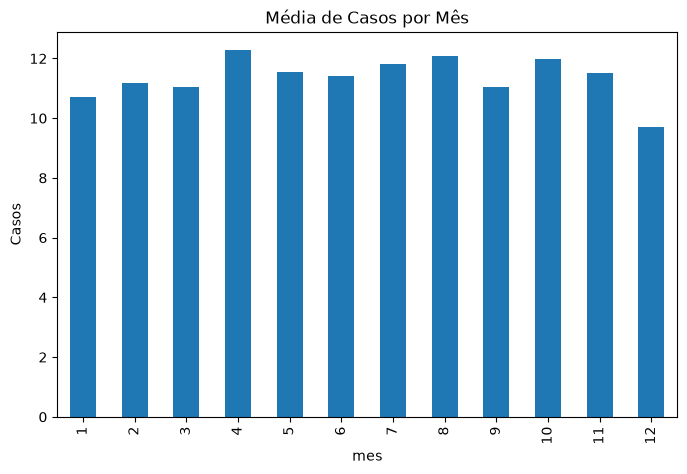

In [8]:
casos_mes = dados.groupby('mes')['casos'].mean()

plt.figure(figsize=(8,5))
casos_mes.plot(kind='bar')
plt.title('Média de Casos por Mês')
plt.ylabel('Casos')
plt.show()

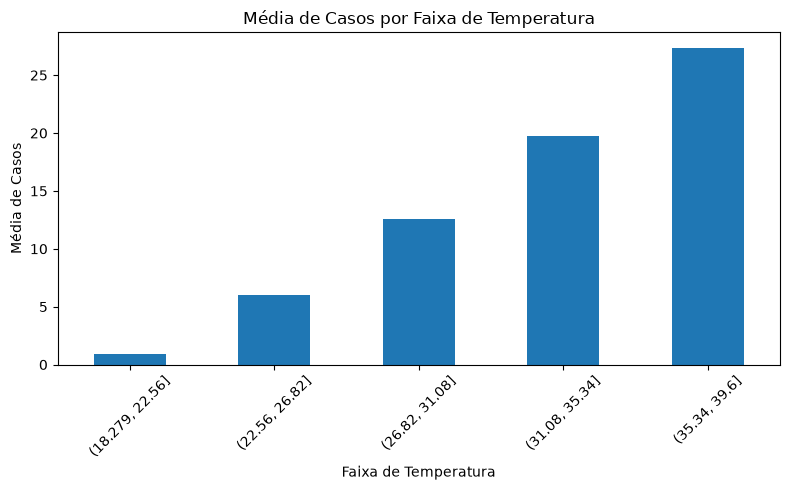

In [9]:
dados['faixa_temperatura'] = pd.cut(
    dados['temperatura'],
    bins=5
)

media_temp = dados.groupby(
    'faixa_temperatura',
    observed=False
)['casos'].mean()

plt.figure(figsize=(8,5))
media_temp.plot(kind='bar')

plt.title('Média de Casos por Faixa de Temperatura')
plt.xlabel('Faixa de Temperatura')
plt.ylabel('Média de Casos')

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

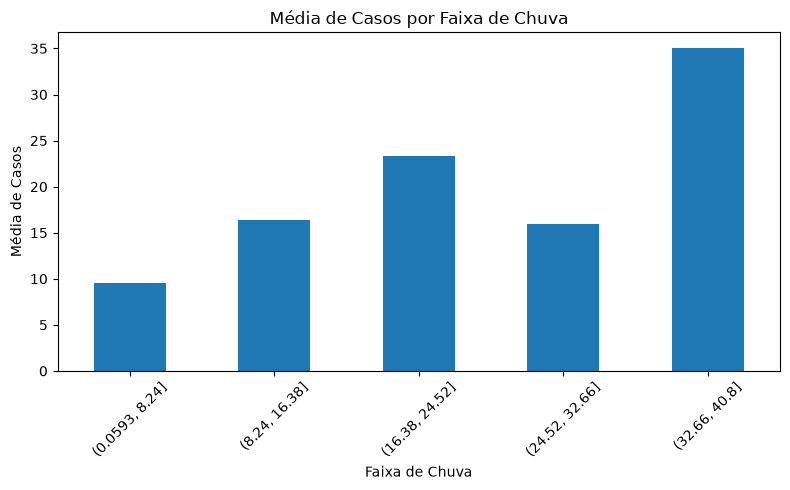

In [10]:
dados['faixa_chuva'] = pd.cut(
    dados['chuva'],
    bins=5
)

media_chuva = dados.groupby(
    'faixa_chuva',
    observed=False
)['casos'].mean()

plt.figure(figsize=(8,5))
media_chuva.plot(kind='bar')

plt.title('Média de Casos por Faixa de Chuva')
plt.xlabel('Faixa de Chuva')
plt.ylabel('Média de Casos')

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [11]:
from sklearn.metrics import r2_score

r2 = r2_score(y_test, previsoes)

print("R²:", round(r2, 4))

R²: 0.6372


In [18]:
comparacao = pd.DataFrame({
    'Modelo': [
        'Random Forest',
        'Regressão Linear'
    ],
    'RMSE': [
        rmse,
        rmse_linear
    ]
})

print(comparacao)

             Modelo      RMSE
0     Random Forest  5.339184
1  Regressão Linear  4.882455


In [17]:
cenarios = pd.DataFrame({
    'temperatura': [22, 25, 39, 35],
    'chuva': [5, 10, 20, 35],
    'umidade': [50, 60, 70, 50],
    'mes': [6, 8, 10, 12]
})

cenarios['casos_previstos'] = modelo.predict(cenarios)

print(cenarios)

   temperatura  chuva  umidade  mes  casos_previstos
0           22      5       50    6             1.61
1           25     10       60    8             8.45
2           39     20       70   10            28.74
3           35     35       50   12            28.62


# Conclusão

Os resultados demonstraram que fatores climáticos como temperatura, chuva e umidade possuem relação com a ocorrência de casos de dengue.

O uso de técnicas de Ciência de Dados permitiu identificar padrões históricos, realizar previsões e construir um simulador de apoio à tomada de decisão.

A solução desenvolvida possui potencial para auxiliar órgãos públicos e profissionais da saúde no planejamento de ações preventivas contra surtos de dengue.

Como trabalhos futuros, o projeto pode ser expandido utilizando bases oficiais mais amplas e variáveis adicionais relacionadas ao ambiente urbano e às condições sanitárias.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
dengue = pd.read_csv('dengue.csv')
clima = pd.read_csv('clima.csv')

In [3]:
dados = pd.merge(
    dengue,
    clima[['data', 'umidade']],
    on='data'
)

dados.head()

,data,temperatura,chuva,casos,umidade
0,2020-01-01,29.5,5.3,7,74.6
1,2020-01-02,27.6,0.6,4,65.6
2,2020-01-03,29.9,9.5,16,66.0
3,2020-01-04,32.6,6.5,14,74.6
4,2020-01-05,27.3,18.2,21,86.5


In [7]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error

X = dados[['temperatura', 'chuva', 'umidade', 'mes']]
y = dados['casos']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

modelo = RandomForestRegressor(n_estimators=100, random_state=42)
modelo.fit(X_train, y_train)

previsoes = modelo.predict(X_test)

mse = mean_squared_error(y_test, previsoes)
rmse = np.sqrt(mse)

print("MSE:", mse)
print("RMSE:", rmse)

MSE: 28.506885
RMSE: 5.339183926406731


In [12]:
novo_dado = pd.DataFrame({
    'temperatura':[32],
    'chuva':[15],
    'umidade':[85],
    'mes':[12]
})

previsao = modelo.predict(novo_dado)

print("Casos previstos:", previsao[0])

Casos previstos: 28.36


In [13]:
from sklearn.linear_model import LinearRegression

modelo_linear = LinearRegression()

modelo_linear.fit(X_train, y_train)

previsoes_linear = modelo_linear.predict(X_test)

rmse_linear = np.sqrt(
    mean_squared_error(
        y_test,
        previsoes_linear
    )
)

print("RMSE Regressão Linear:", rmse_linear)

RMSE Regressão Linear: 4.882454767378238


In [16]:
casos_previstos = previsao[0]

if casos_previstos < 30:
    risco = "BAIXO"
elif casos_previstos < 60:
    risco = "MÉDIO"
else:
    risco = "ALTO"

print(f"Risco de surto: {risco}")

Risco de surto: BAIXO
